<a href="https://colab.research.google.com/github/Dhruvikaa001/Ernst-Young-Project-1/blob/main/tat_threshold_breach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import joblib
from google.colab import files

In [5]:
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded.keys())))

Saving generated_pr_to_po_dataset.csv to generated_pr_to_po_dataset.csv


In [6]:
df.head()

,PR_Number,PR_Date,PO_Date,TAT_Days,TAT_Breach,PR_Type,Department,Requester,Material_Group,Material,PR_Amount,Plant,Approver_Level,Vendor,Buyer,PO_Amount,Vendor_History_Avg_Leadtime,Season
0,PR_1,2020-04-12,2020-04-13,1,0,NB,HR,Requester_1,SPARE_PARTS,MAT8713,3139.832976,Plant_C,3,Vendor_19,Buyer_25,8614.744629,10.287234,Q4
1,PR_2,2020-12-14,2020-12-22,8,1,ZB,Finance,Requester_2,FINISHED_GOODS,MAT6818,1726.921985,Plant_A,2,Vendor_23,Buyer_4,1339.964886,6.507821,Q1
2,PR_3,2020-09-27,2020-10-06,9,1,ZB,IT,Requester_3,SPARE_PARTS,MAT6865,6535.501371,Plant_D,1,Vendor_11,Buyer_18,6643.856334,12.949837,Q3
3,PR_4,2020-04-16,2020-04-21,5,0,ZB,IT,Requester_4,RAW_MAT,MAT2092,2256.230469,Plant_D,3,Vendor_45,Buyer_21,8875.623988,9.277531,Q1
4,PR_5,2020-03-12,2020-03-17,5,0,NB,Finance,Requester_5,SPARE_PARTS,MAT6721,5607.093197,Plant_C,1,Vendor_26,Buyer_2,3938.434041,7.158979,Q1


In [7]:
# Convert dates and calculate target
df['TAT_Days'] = (pd.to_datetime(df['PO_Date']) - pd.to_datetime(df['PR_Date'])).dt.days
df['TAT_Breach'] = (df['TAT_Days'] > 7).astype(int)

In [8]:
# Feature Engineering
df['Amount_to_Dept_Avg'] = df['PR_Amount'] / df.groupby('Department')['PR_Amount'].transform('mean')
df['Vendor_Risk_Score'] = df.groupby('Vendor')['TAT_Breach'].transform('mean')
df['Approver_Workload'] = df.groupby('Approver_Level')['PR_Number'].transform('count')
df['Complexity_Score'] = np.log1p(df['PR_Amount']) * df['Approver_Level']
df['PR_Day_of_Week'] = pd.to_datetime(df['PR_Date']).dt.dayofweek
df['Amount_Approver_Interaction'] = df['PR_Amount'] * df['Approver_Level']

In [9]:
# Lag feature for vendor history (example)
df['Vendor_Last_3_Delays'] = df.groupby('Vendor')['TAT_Breach'].transform(lambda x: x.rolling(3, min_periods=1).mean())

In [10]:
# Selected features
features = [
    'Amount_to_Dept_Avg',
    'Vendor_Risk_Score',
    'Approver_Workload',
    'Complexity_Score',
    'Vendor_History_Avg_Leadtime',
    'PR_Day_of_Week',
    'Amount_Approver_Interaction',
    'Vendor_Last_3_Delays'
]
X = df[features]
y = df['TAT_Breach']

In [11]:
# ----------------------------
# 2. Handle Class Imbalance
# ----------------------------
# Calculate class weight ratio
scale_pos_weight = len(y[y == 0]) / len(y[y == 1])
# Apply SMOTE oversampling
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
# Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)
# Split training set further for validation (for early stopping)
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [12]:

# ----------------------------
# 3. Hyperparameter Tuning
# ----------------------------
# Parameter grid
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'gamma': [0, 0.1],
    'scale_pos_weight': [1, 2]
}


In [13]:

# Base model (disable early stopping during search)
model = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss'
)

In [14]:
# Randomized search
search = RandomizedSearchCV(
    model,
    param_distributions=params,
    n_iter=10,  # Reduced for stability
    scoring='f1',
    cv=3,  # Fewer folds for speed
    verbose=1,
    random_state=42,
    error_score='raise'  # To catch any issues
)

search.fit(X_train_fit, y_train_fit)
best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [15]:
# Best model
best_model = search.best_estimator_
print(f"Best parameters: {search.best_params_}")


Best parameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [16]:
# Get predicted probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]


In [18]:
# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

In [19]:
# Apply threshold
y_pred = (y_proba >= optimal_threshold).astype(int)

In [20]:
# ----------------------------
# 5. Evaluation
# ----------------------------
print("\n=== Optimized Model Performance ===")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))


=== Optimized Model Performance ===
Optimal Threshold: 0.510
F1-Score: 0.845
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      6986
           1       0.79      0.91      0.85      6985

    accuracy                           0.83     13971
   macro avg       0.84      0.83      0.83     13971
weighted avg       0.84      0.83      0.83     13971



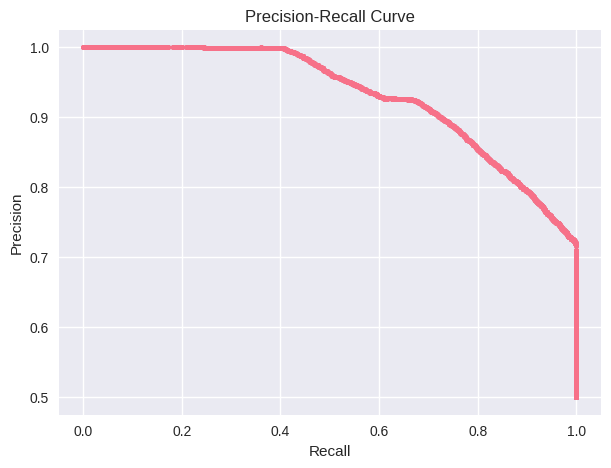

In [21]:
# Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [22]:
# ----------------------------
# 6. Save Model
# ----------------------------
joblib.dump(best_model, 'optimized_delay_predictor.joblib')
print("Model saved as optimized_delay_predictor.joblib")

Model saved as optimized_delay_predictor.joblib


Creating enhanced visualizations...


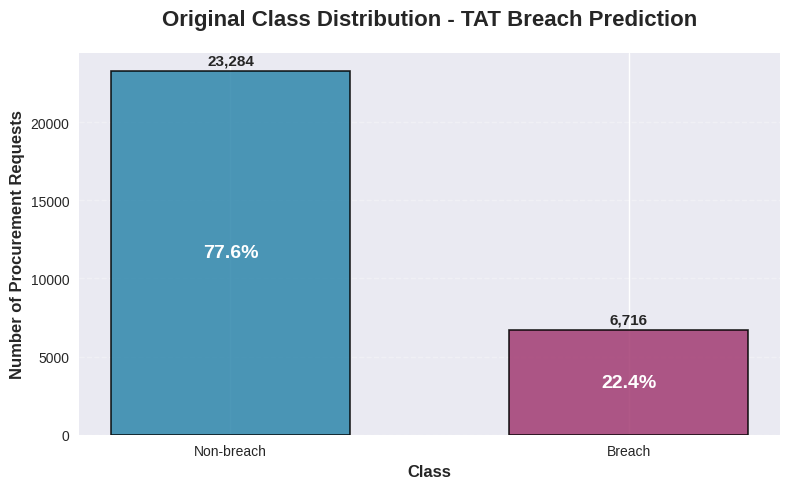

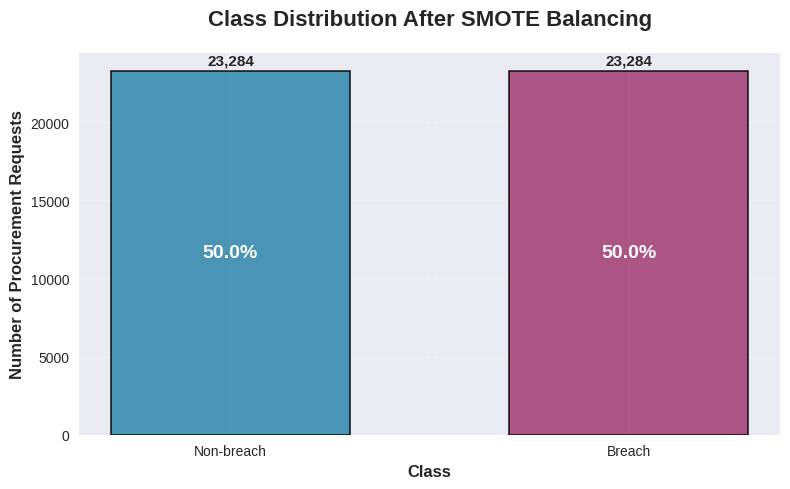

CLASS DISTRIBUTION ANALYSIS
Original dataset: 30,000 total records
  - Non-breach: 23,284 (77.6%)
  - Breach: 6,716 (22.4%)
After SMOTE: 46,568 total records
  - Non-breach: 23,284 (50.0%)
  - Breach: 23,284 (50.0%)


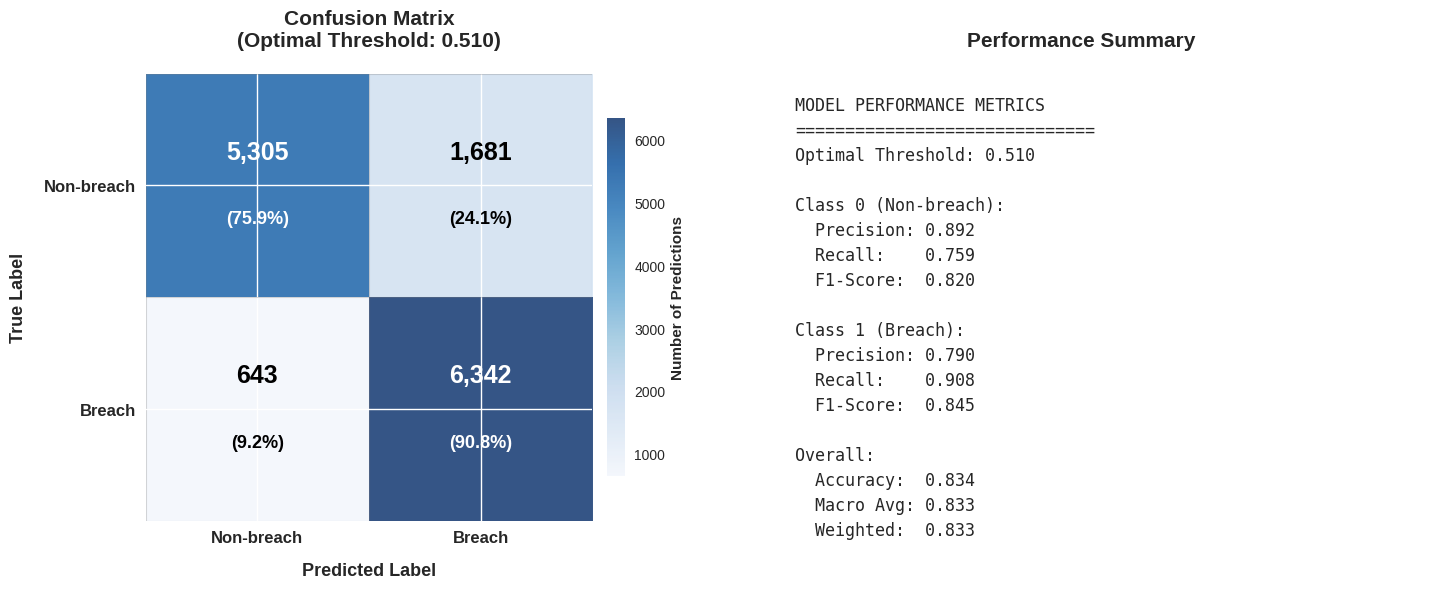

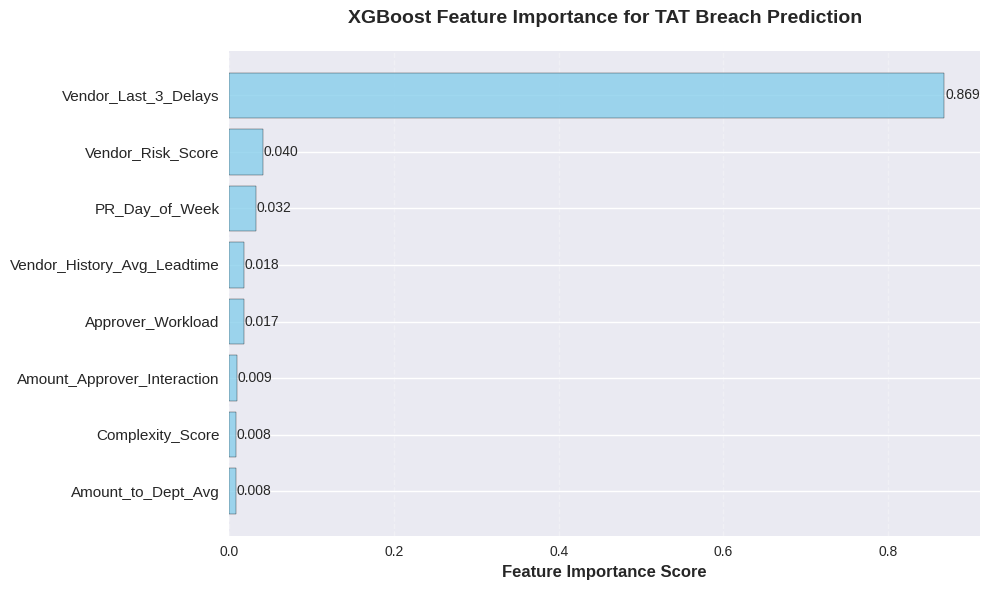

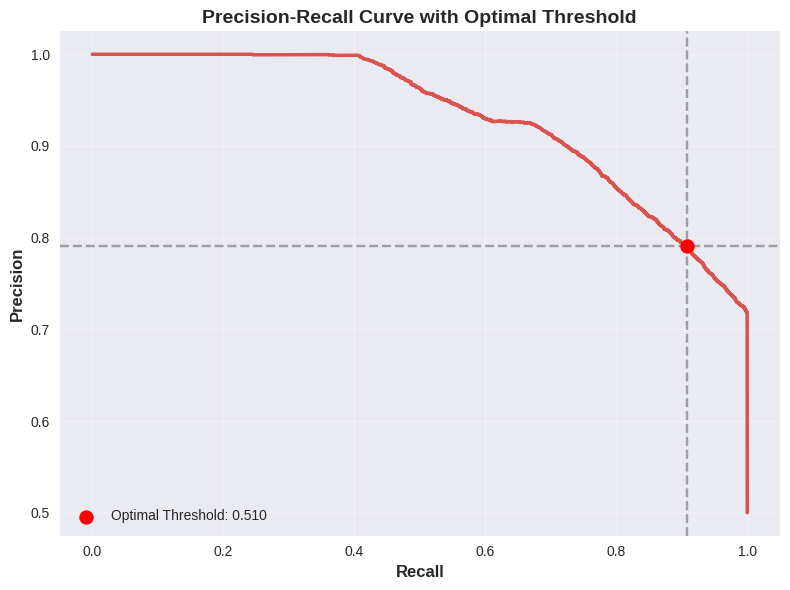

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, f1_score

# Set professional styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create a function for better value annotations on bars
def add_value_labels(ax, bars, fontsize=11, offset_factor=0.01):
    """Add value labels on top of bars"""
    max_height = max([bar.get_height() for bar in bars])
    offset = max_height * offset_factor

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                f'{int(height):,}',  # Format with commas for thousands
                ha='center', va='bottom',
                fontsize=fontsize, fontweight='bold')

# 1) Enhanced Class distribution before & after SMOTE
classes = ['Non‑breach', 'Breach']
colors = ['#2E86AB', '#A23B72']  # Professional color scheme

print("Creating enhanced visualizations...")

# Original distribution
plt.figure(figsize=(8, 5))
orig_counts = np.bincount(y)
bars_orig = plt.bar(classes, orig_counts, color=colors, alpha=0.85,
                   edgecolor='black', linewidth=1.2, width=0.6)

plt.title('Original Class Distribution - TAT Breach Prediction',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Procurement Requests', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels and percentage
total_orig = sum(orig_counts)
for i, bar in enumerate(bars_orig):
    height = bar.get_height()
    percentage = (height / total_orig) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height/2,
             f'{percentage:.1f}%', ha='center', va='center',
             fontsize=14, fontweight='bold', color='white')

add_value_labels(plt.gca(), bars_orig)
plt.tight_layout()
plt.show()

# After SMOTE distribution
plt.figure(figsize=(8, 5))
res_counts = np.bincount(y_resampled)
bars_res = plt.bar(classes, res_counts, color=colors, alpha=0.85,
                  edgecolor='black', linewidth=1.2, width=0.6)

plt.title('Class Distribution After SMOTE Balancing',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Procurement Requests', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels and percentage
total_res = sum(res_counts)
for i, bar in enumerate(bars_res):
    height = bar.get_height()
    percentage = (height / total_res) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height/2,
             f'{percentage:.1f}%', ha='center', va='center',
             fontsize=14, fontweight='bold', color='white')

add_value_labels(plt.gca(), bars_res)
plt.tight_layout()
plt.show()

# Print distribution statistics
print("="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)
print(f"Original dataset: {len(y):,} total records")
print(f"  - Non-breach: {orig_counts[0]:,} ({orig_counts[0]/len(y)*100:.1f}%)")
print(f"  - Breach: {orig_counts[1]:,} ({orig_counts[1]/len(y)*100:.1f}%)")
print(f"After SMOTE: {len(y_resampled):,} total records")
print(f"  - Non-breach: {res_counts[0]:,} ({res_counts[0]/len(y_resampled)*100:.1f}%)")
print(f"  - Breach: {res_counts[1]:,} ({res_counts[1]/len(y_resampled)*100:.1f}%)")
print("="*60)

# 2) Enhanced Confusion matrix at optimized threshold
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= optimal_threshold).astype(int)

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create subplot for confusion matrix and metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
im = ax1.imshow(cm, cmap='Blues', alpha=0.8, aspect='equal')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(classes, fontsize=12, fontweight='bold')
ax1.set_yticklabels(classes, fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=13, fontweight='bold', labelpad=12)
ax1.set_ylabel('True Label', fontsize=13, fontweight='bold', labelpad=12)
ax1.set_title(f'Confusion Matrix\n(Optimal Threshold: {optimal_threshold:.3f})',
              fontsize=15, fontweight='bold', pad=20)

# Add grid lines
ax1.set_xticks([-0.5, 0.5, 1.5], minor=True)
ax1.set_yticks([-0.5, 0.5, 1.5], minor=True)
ax1.grid(which="minor", color="gray", linestyle='-', linewidth=0.8, alpha=0.3)
ax1.tick_params(which="minor", size=0)

# Annotate with both counts and percentages
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax1.text(j, i-0.15, f'{cm[i, j]:,}',
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')
        ax1.text(j, i+0.15, f'({cm_percent[i, j]:.1f}%)',
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

# Add colorbar
cbar = plt.colorbar(im, ax=ax1, shrink=0.8, pad=0.02)
cbar.set_label('Number of Predictions', fontsize=11, fontweight='bold')

# Performance Metrics Summary
metrics = classification_report(y_test, y_pred, output_dict=True)
metrics_text = [
    "MODEL PERFORMANCE METRICS",
    "=" * 30,
    f"Optimal Threshold: {optimal_threshold:.3f}",
    "",
    "Class 0 (Non-breach):",
    f"  Precision: {metrics['0']['precision']:.3f}",
    f"  Recall:    {metrics['0']['recall']:.3f}",
    f"  F1-Score:  {metrics['0']['f1-score']:.3f}",
    "",
    "Class 1 (Breach):",
    f"  Precision: {metrics['1']['precision']:.3f}",
    f"  Recall:    {metrics['1']['recall']:.3f}",
    f"  F1-Score:  {metrics['1']['f1-score']:.3f}",
    "",
    "Overall:",
    f"  Accuracy:  {metrics['accuracy']:.3f}",
    f"  Macro Avg: {metrics['macro avg']['f1-score']:.3f}",
    f"  Weighted:  {metrics['weighted avg']['f1-score']:.3f}"
]

ax2.text(0.1, 0.95, '\n'.join(metrics_text), transform=ax2.transAxes,
         fontfamily='monospace', fontsize=12, va='top', linespacing=1.5)
ax2.set_title('Performance Summary', fontsize=15, fontweight='bold', pad=20)
ax2.axis('off')

plt.tight_layout()
plt.show()

# 3) Additional Visualization: Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = best_model.feature_importances_
feature_names = features
indices = np.argsort(feature_importance)[::-1]

# Create horizontal bar plot
bars = plt.barh(range(len(feature_importance)),
                feature_importance[indices],
                color='skyblue', edgecolor='black', alpha=0.8)
plt.yticks(range(len(feature_importance)),
           [feature_names[i] for i in indices], fontsize=11)
plt.xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
plt.title('XGBoost Feature Importance for TAT Breach Prediction',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 4) Precision-Recall Curve with Optimal Threshold
plt.figure(figsize=(8, 6))
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

plt.plot(recalls, precisions, linewidth=2.5, color='#D9534F')
plt.axvline(x=recalls[np.argmax(f1_scores)], color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=precisions[np.argmax(f1_scores)], color='gray', linestyle='--', alpha=0.7)
plt.scatter(recalls[np.argmax(f1_scores)], precisions[np.argmax(f1_scores)],
            color='red', s=100, zorder=5, label=f'Optimal Threshold: {optimal_threshold:.3f}')

plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve with Optimal Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
